# Лабораторная 4 — Генерация лиц на CelebA (WGAN-GP)

**Дедлайн:** 12.03 · **Баллов:** 10

**Датасет:** CelebA — https://www.kaggle.com/datasets/jessicali9530/celeba-dataset

**Ход работы:**

- Подготовка датасета: использовать детектор/сегментатор для предварительного вырезания лиц людей.
- Можно добавить технику выравнивания лица (не обязательно).
- Обучить **VAE** или **GAN** для задачи **безусловной** генерации лиц.
- Затем эту же сеть преобразовать в **условную** и обучить для условной генерации лиц по полу человека (или другому признаку).
- **Метрики:** посчитать FID и IS, показать кривые обучения.
- Погуглить и почитать, какие техники и улучшения стоит добавить в VAE/GAN, чтобы они лучше обучились (например, вместо простого GAN — WGAN с градиентным штрафом).

**Пайплайн:**
1. Загрузка CelebA, MTCNN-кроп + выравнивание лиц 64×64 с кэшированием на диск.
2. Безусловный **WGAN-GP** (DCGAN-backbone, gradient penalty, n_critic=5, Adam(β=(0, 0.9))).
3. Тот же backbone в условном варианте **cWGAN-GP** по атрибуту `Male`.
4. **FID + IS** через `torchmetrics`, кривые обучения и сэмпл-гриды.

## 1. Установка и импорты

In [1]:
import importlib, subprocess, sys

def _ensure(pip_name, import_name=None):
    try:
        importlib.import_module(import_name or pip_name)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=True)

for _pip, _imp in [("kagglehub", "kagglehub"), ("facenet-pytorch", "facenet_pytorch"),
                   ("torchmetrics", "torchmetrics"), ("torch-fidelity", "torch_fidelity")]:
    _ensure(_pip, _imp)

import os, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torchvision.utils as vutils
from torch.utils.data import Dataset, DataLoader

IN_COLAB = "google.colab" in sys.modules
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

/home/greg/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | NVIDIA GeForce RTX 4070 Laptop GPU


## 2. Конфигурация


In [2]:
VALIDATION  = False

IMG_SIZE    = 64
ATTR        = "Male"
SUBSET_SIZE = 3_000 if VALIDATION else 50_000

Z_DIM       = 128
NGF         = 64
NDF         = 64
EMBED_DIM   = 64

BATCH_SIZE  = 64
N_CRITIC    = 5
LAMBDA_GP   = 10
LR          = 1e-4
BETAS       = (0.0, 0.9)
NUM_EPOCHS  = 1 if VALIDATION else 80

FID_EVERY   = 1 if VALIDATION else 5
FID_N       = 512 if VALIDATION else 5_000

LAB_DIR  = Path(".")
DATA_DIR = LAB_DIR / "data"
SAMP_DIR = LAB_DIR / "samples"
DATA_DIR.mkdir(parents=True, exist_ok=True)
SAMP_DIR.mkdir(parents=True, exist_ok=True)

print(f"VALIDATION={VALIDATION} | subset={SUBSET_SIZE} | epochs={NUM_EPOCHS} | FID_N={FID_N}")

VALIDATION=False | subset=50000 | epochs=80 | FID_N=5000


## 3. Загрузка CelebA и парсинг атрибутов


In [3]:
import kagglehub

_token_file = Path.home() / ".kaggle" / "access_token"
if _token_file.exists():
    kagglehub.auth.set_kaggle_api_token(_token_file.read_text().strip())
elif not (Path.home() / ".kaggle" / "kaggle.json").exists() and "KAGGLE_USERNAME" not in os.environ:
    raise RuntimeError(
        "Kaggle credentials not found. Provide one of: ~/.kaggle/access_token (single API "
        "token), ~/.kaggle/kaggle.json, or KAGGLE_USERNAME/KAGGLE_KEY env vars."
    )
print("Authenticated as:", kagglehub.whoami()["username"])

ds_path = Path(kagglehub.dataset_download("jessicali9530/celeba-dataset"))
print("Dataset cached at:", ds_path)

img_root = next(ds_path.rglob("img_align_celeba"))
if (img_root / "img_align_celeba").is_dir():
    img_root = img_root / "img_align_celeba"
attr_csv = next(ds_path.rglob("list_attr_celeba.csv"))

attrs = pd.read_csv(attr_csv)
attrs = attrs.set_index(attrs.columns[0])
assert ATTR in attrs.columns, f"{ATTR} not in attributes: {list(attrs.columns)[:5]}..."
print("Images dir:", img_root, "| attributes table:", attrs.shape)

ids = np.array(attrs.index)
sel = np.random.default_rng(SEED).permutation(len(ids))[:SUBSET_SIZE]
files_subset  = [img_root / ids[i] for i in sel]
labels_subset = [(1 if attrs[ATTR].iloc[i] == 1 else 0) for i in sel]
print(f"Subset: {len(files_subset)} images | "
      f"{ATTR}=1: {sum(labels_subset)}  {ATTR}=0: {len(labels_subset)-sum(labels_subset)}")

Kaggle credentials set.
Kaggle credentials successfully validated.
Authenticated as: gpevnev
Dataset cached at: /home/greg/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2
Images dir: /home/greg/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2/img_align_celeba/img_align_celeba | attributes table: (202599, 40)
Subset: 50000 images | Male=1: 20961  Male=0: 29039


  3%|▎         | 38.0M/1.33G [00:01<00:34, 40.2MB/s]

  3%|▎         | 43.0M/1.33G [00:01<00:32, 42.6MB/s]

  4%|▎         | 48.0M/1.33G [00:01<00:34, 40.2MB/s]

  4%|▍         | 53.0M/1.33G [00:01<00:35, 38.7MB/s]

...

100%|█████████▉| 1.33G/1.33G [00:35<00:00, 47.0MB/s]

100%|██████████| 1.33G/1.33G [00:35<00:00, 40.1MB/s]

Extracting files...


Dataset cached at: /home/greg/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2


Images dir: /home/greg/.cache/kagglehub/datasets/jessicali9530/celeba-dataset/versions/2/img_align_celeba/img_align_celeba | attributes table: (202599, 40)
Subset: 3000 images | Male=1: 1258  Male=0: 1742


## 4. Детекция и выравнивание лиц через MTCNN


In [4]:
from facenet_pytorch import MTCNN

CROPS_PT  = DATA_DIR / f"celeba_crops_{IMG_SIZE}_{SUBSET_SIZE}.pt"
LABELS_PT = DATA_DIR / f"celeba_labels_{SUBSET_SIZE}.pt"

if CROPS_PT.exists() and LABELS_PT.exists():
    crops_uint8 = torch.load(CROPS_PT)
    labels_all  = torch.load(LABELS_PT)
    print(f"Loaded cached crops: {tuple(crops_uint8.shape)}")
else:
    mtcnn = MTCNN(image_size=IMG_SIZE, margin=0, post_process=False,
                  select_largest=True, device=device)
    crops, labs, n_miss = [], [], 0
    for fpath, lab in tqdm(list(zip(files_subset, labels_subset)), desc="MTCNN crop+align"):
        try:
            face = mtcnn(Image.open(fpath).convert("RGB"))
        except Exception:
            face = None
        if face is None:
            n_miss += 1
            continue
        crops.append(face.round().clamp(0, 255).to(torch.uint8))
        labs.append(lab)
    crops_uint8 = torch.stack(crops)
    labels_all  = torch.tensor(labs, dtype=torch.uint8)
    torch.save(crops_uint8, CROPS_PT)
    torch.save(labels_all,  LABELS_PT)
    del mtcnn
    torch.cuda.empty_cache()
    print(f"Built crops: {tuple(crops_uint8.shape)} | faces missed: {n_miss}")

print(f"{ATTR}=1: {(labels_all==1).sum().item()} | {ATTR}=0: {(labels_all==0).sum().item()}")

/tmp/ipykernel_359026/1255120117.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  crops_uint8 = torch.load(CROPS_PT)


Loaded cached crops: (49925, 3, 64, 64)
Male=1: 20922 | Male=0: 29003


/tmp/ipykernel_359026/1255120117.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  labels_all  = torch.load(LABELS_PT)


MTCNN crop+align:   0%|          | 13/3000 [00:00<02:06, 23.63it/s]

MTCNN crop+align:   1%|          | 18/3000 [00:00<01:48, 27.48it/s]

...

MTCNN crop+align: 100%|█████████▉| 2989/3000 [01:22<00:00, 35.71it/s]

MTCNN crop+align: 100%|█████████▉| 2993/3000 [01:23<00:00, 36.07it/s]

MTCNN crop+align: 100%|█████████▉| 2997/3000 [01:23<00:00, 36.00it/s]

MTCNN crop+align: 100%|██████████| 3000/3000 [01:23<00:00, 36.06it/s]

Built crops: (2998, 3, 64, 64) | faces missed: 2
Male=1: 1257 | Male=0: 1741


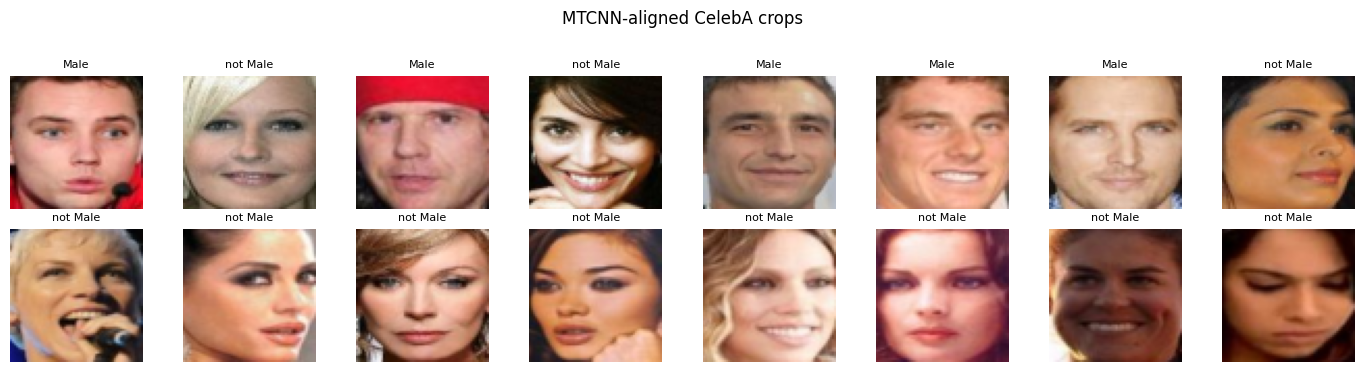

In [5]:
fig, axes = plt.subplots(2, 8, figsize=(14, 3.6))
for ax, idx in zip(axes.flat, torch.randperm(crops_uint8.size(0))[:16]):
    ax.imshow(crops_uint8[idx].permute(1, 2, 0).numpy())
    ax.set_title(ATTR if labels_all[idx] == 1 else f"not {ATTR}", fontsize=8)
    ax.axis("off")
fig.suptitle("MTCNN-aligned CelebA crops", y=1.02)
plt.tight_layout(); plt.show()

## 5. Dataset и DataLoader


In [6]:
class CelebACrops(Dataset):
    def __init__(self, crops_uint8, labels=None):
        self.crops = crops_uint8
        self.labels = labels

    def __len__(self):
        return self.crops.size(0)

    def __getitem__(self, i):
        img = self.crops[i].float().div_(127.5).sub_(1.0)
        if self.labels is None:
            return img
        return img, int(self.labels[i])

_dl_kwargs = dict(batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
                  num_workers=2, pin_memory=True)

uncond_loader = DataLoader(CelebACrops(crops_uint8), **_dl_kwargs)
cond_loader   = DataLoader(CelebACrops(crops_uint8, labels_all), **_dl_kwargs)
print(f"{len(uncond_loader)} batches/epoch @ batch_size={BATCH_SIZE}")

780 batches/epoch @ batch_size=64


## 6. Модель WGAN-GP


In [7]:
def build_generator_net(in_channels, ngf=NGF):
    def block(i, o):
        return nn.Sequential(nn.ConvTranspose2d(i, o, 4, 2, 1, bias=False),
                             nn.BatchNorm2d(o), nn.ReLU(True))
    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, ngf * 8, 4, 1, 0, bias=False),
        nn.BatchNorm2d(ngf * 8), nn.ReLU(True),
        block(ngf * 8, ngf * 4),
        block(ngf * 4, ngf * 2),
        block(ngf * 2, ngf),
        nn.ConvTranspose2d(ngf, 3, 4, 2, 1),
        nn.Tanh(),
    )

def build_critic_net(in_channels, ndf=NDF):
    def block(i, o):
        return nn.Sequential(nn.Conv2d(i, o, 4, 2, 1),
                             nn.InstanceNorm2d(o, affine=True), nn.LeakyReLU(0.2, True))
    return nn.Sequential(
        nn.Conv2d(in_channels, ndf, 4, 2, 1), nn.LeakyReLU(0.2, True),
        block(ndf, ndf * 2),
        block(ndf * 2, ndf * 4),
        block(ndf * 4, ndf * 8),
        nn.Conv2d(ndf * 8, 1, 4, 1, 0),
    )

class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, ngf=NGF):
        super().__init__()
        self.net = build_generator_net(z_dim, ngf)
    def forward(self, z):
        return self.net(z)

class Critic(nn.Module):
    def __init__(self, ndf=NDF):
        super().__init__()
        self.net = build_critic_net(3, ndf)
    def forward(self, x):
        return self.net(x).view(-1)

def weights_init(m):
    cn = m.__class__.__name__
    if "Conv" in cn:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cn and m.weight is not None:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0.0)

def gradient_penalty(critic, real, fake, labels=None):
    n = real.size(0)
    eps = torch.rand(n, 1, 1, 1, device=real.device)
    x_hat = (eps * real + (1 - eps) * fake).requires_grad_(True)
    scores = critic(x_hat) if labels is None else critic(x_hat, labels)
    grad = torch.autograd.grad(
        outputs=scores, inputs=x_hat,
        grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True,
    )[0].view(n, -1)
    return ((grad.norm(2, dim=1) - 1) ** 2).mean()

_g, _c = Generator().to(device), Critic().to(device)
with torch.no_grad():
    _z = torch.randn(4, Z_DIM, 1, 1, device=device)
    print("G out:", tuple(_g(_z).shape), "| C out:", tuple(_c(_g(_z)).shape))
del _g, _c

G out: (4, 3, 64, 64) | C out: (4,)


## 7. Утилиты обучения


In [8]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore

def _to_uint8(imgs):
    return ((imgs.clamp(-1, 1) + 1) * 127.5).to(torch.uint8)

@torch.no_grad()
def evaluate_fid_is(gen, real_uint8, n_samples, z_dim, device,
                    n_classes=None, batch=128):
    gen.eval()
    fid = FrechetInceptionDistance(feature=2048, normalize=False).to(device)
    iscore = InceptionScore(normalize=False).to(device)

    n = min(n_samples, real_uint8.size(0))
    idx = torch.randperm(real_uint8.size(0))[:n]
    for i in range(0, n, batch):
        fid.update(real_uint8[idx[i:i + batch]].to(device), real=True)

    done = 0
    while done < n:
        b = min(batch, n - done)
        z = torch.randn(b, z_dim, 1, 1, device=device)
        if n_classes is None:
            fake = gen(z)
        else:
            lbl = torch.randint(0, n_classes, (b,), device=device)
            fake = gen(z, lbl)
        fake = _to_uint8(fake)
        fid.update(fake, real=False)
        iscore.update(fake)
        done += b

    f = fid.compute().item()
    is_mean, is_std = iscore.compute()
    del fid, iscore
    torch.cuda.empty_cache()
    gen.train()
    return f, is_mean.item(), is_std.item()

@torch.no_grad()
def sample_grid(gen, fixed_z, labels=None, nrow=8):
    gen.eval()
    imgs = gen(fixed_z) if labels is None else gen(fixed_z, labels)
    grid = vutils.make_grid((imgs.clamp(-1, 1) + 1) / 2, nrow=nrow).cpu()
    gen.train()
    return grid.permute(1, 2, 0).numpy()

def save_ckpt(path, gen, critic, opt_g, opt_c, epoch, history, best_fid, fixed_z):
    torch.save({"gen": gen.state_dict(), "critic": critic.state_dict(),
                "opt_g": opt_g.state_dict(), "opt_c": opt_c.state_dict(),
                "epoch": epoch, "history": history, "best_fid": best_fid,
                "fixed_z": fixed_z.cpu()}, path)

def load_ckpt(path, gen, critic, opt_g, opt_c, device):
    ck = torch.load(path, map_location=device)
    gen.load_state_dict(ck["gen"]); critic.load_state_dict(ck["critic"])
    opt_g.load_state_dict(ck["opt_g"]); opt_c.load_state_dict(ck["opt_c"])
    return ck["epoch"] + 1, ck["history"], ck["best_fid"], ck["fixed_z"].to(device)

## 8. Обучение — безусловный WGAN-GP


In [9]:
def train_wgan_gp(gen, critic, loader, num_epochs, ckpt_last, ckpt_best, samp_prefix,
                  n_classes=None):
    opt_g = torch.optim.Adam(gen.parameters(), lr=LR, betas=BETAS)
    opt_c = torch.optim.Adam(critic.parameters(), lr=LR, betas=BETAS)
    history = {"w_dist": [], "g_loss": [], "fid": [], "is": [], "fid_epoch": []}
    fixed_z = torch.randn(64, Z_DIM, 1, 1, device=device)
    start, best_fid = 0, float("inf")
    if Path(ckpt_last).exists():
        start, history, best_fid, fixed_z = load_ckpt(ckpt_last, gen, critic, opt_g, opt_c, device)
        print(f"Resumed from checkpoint at epoch {start}")
    fixed_lbl = None if n_classes is None else \
        (torch.arange(64, device=device) >= 32).long()

    for epoch in range(start, num_epochs):
        gen.train(); critic.train()
        run_w = run_g = 0.0; nb = 0
        pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        for batch in pbar:
            if n_classes is None:
                real, lbl = batch.to(device, non_blocking=True), None
            else:
                real, lbl = batch
                real, lbl = real.to(device, non_blocking=True), lbl.to(device)
            bs = real.size(0)

            for _ in range(N_CRITIC):
                z = torch.randn(bs, Z_DIM, 1, 1, device=device)
                fake = gen(z) if lbl is None else gen(z, lbl)
                c_real = critic(real) if lbl is None else critic(real, lbl)
                c_fake = critic(fake.detach()) if lbl is None else critic(fake.detach(), lbl)
                gp = gradient_penalty(critic, real, fake.detach(), lbl)
                loss_c = c_fake.mean() - c_real.mean() + LAMBDA_GP * gp
                opt_c.zero_grad(set_to_none=True); loss_c.backward(); opt_c.step()
            w_dist = (c_real.mean() - c_fake.mean()).item()

            z = torch.randn(bs, Z_DIM, 1, 1, device=device)
            fake = gen(z) if lbl is None else gen(z, lbl)
            loss_g = -(critic(fake) if lbl is None else critic(fake, lbl)).mean()
            opt_g.zero_grad(set_to_none=True); loss_g.backward(); opt_g.step()

            run_w += w_dist; run_g += loss_g.item(); nb += 1
            pbar.set_postfix(w_dist=f"{w_dist:.2f}", g_loss=f"{loss_g.item():.2f}")

        history["w_dist"].append(run_w / nb); history["g_loss"].append(run_g / nb)
        fid_str = ""
        if (epoch + 1) % FID_EVERY == 0 or epoch == num_epochs - 1:
            f, ism, _ = evaluate_fid_is(gen, crops_uint8, FID_N, Z_DIM, device, n_classes)
            history["fid"].append(f); history["is"].append(ism); history["fid_epoch"].append(epoch + 1)
            if f < best_fid:
                best_fid = f
                save_ckpt(ckpt_best, gen, critic, opt_g, opt_c, epoch, history, best_fid, fixed_z)
            fid_str = f" | FID {f:5.1f} | IS {ism:.2f}"

        plt.imsave(f"{samp_prefix}_epoch_{epoch+1:03d}.png", sample_grid(gen, fixed_z, fixed_lbl))
        save_ckpt(ckpt_last, gen, critic, opt_g, opt_c, epoch, history, best_fid, fixed_z)
        print(f"Epoch {epoch+1:3d}/{num_epochs} | W-dist {run_w/nb:7.2f} | "
              f"G-loss {run_g/nb:8.2f}{fid_str}")
    return history, fixed_z, fixed_lbl


def plot_curves(history, title):
    ep_w = range(1, len(history["w_dist"]) + 1)
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    ax[0].plot(ep_w, history["w_dist"]); ax[0].axhline(0, ls="--", c="gray", lw=.8)
    ax[0].set_title("Wasserstein distance estimate"); ax[0].set_xlabel("epoch")
    ax[1].plot(ep_w, history["g_loss"], c="tab:orange")
    ax[1].set_title("Generator loss"); ax[1].set_xlabel("epoch")
    if history["fid"]:
        ax[2].plot(history["fid_epoch"], history["fid"], "-o", c="tab:green", label="FID")
        ax[2].set_ylabel("FID"); axb = ax[2].twinx()
        axb.plot(history["fid_epoch"], history["is"], "-s", c="tab:red", label="IS")
        axb.set_ylabel("IS")
    ax[2].set_title("FID / IS"); ax[2].set_xlabel("epoch")
    fig.suptitle(title); plt.tight_layout(); plt.show()

In [10]:
gen = Generator().to(device);  gen.apply(weights_init)
critic = Critic().to(device);  critic.apply(weights_init)

uncond_history, uncond_fixed_z, _ = train_wgan_gp(
    gen, critic, uncond_loader, NUM_EPOCHS,
    ckpt_last=LAB_DIR / "wgan_last.pth",
    ckpt_best=LAB_DIR / "wgan_best.pth",
    samp_prefix=str(SAMP_DIR / "uncond"),
)

Resumed from checkpoint at epoch 80


/tmp/ipykernel_359026/797567245.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(path, map_location=device)


Epoch 1/1:   4%|▍         | 2/46 [00:01<00:22,  1.97it/s, g_loss=1.34, w_dist=3.49]

Epoch 1/1:   7%|▋         | 3/46 [00:01<00:16,  2.63it/s, g_loss=1.34, w_dist=3.49]

Epoch 1/1:   7%|▋         | 3/46 [00:01<00:16,  2.63it/s, g_loss=2.38, w_dist=4.62]

...

Epoch 1/1:  98%|█████████▊| 45/46 [00:10<00:00,  4.77it/s, g_loss=51.08, w_dist=51.60]

Epoch 1/1:  98%|█████████▊| 45/46 [00:11<00:00,  4.77it/s, g_loss=42.72, w_dist=49.37]

Epoch 1/1: 100%|██████████| 46/46 [00:11<00:00,  4.77it/s, g_loss=42.72, w_dist=49.37]

/home/greg/miniconda3/envs/ml/lib/python3.11/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Epoch   1/1 | W-dist   49.40 | G-loss    38.70 | FID 306.9 | IS 1.64


## 9. Безусловная модель — кривые, сэмплы, финальные метрики

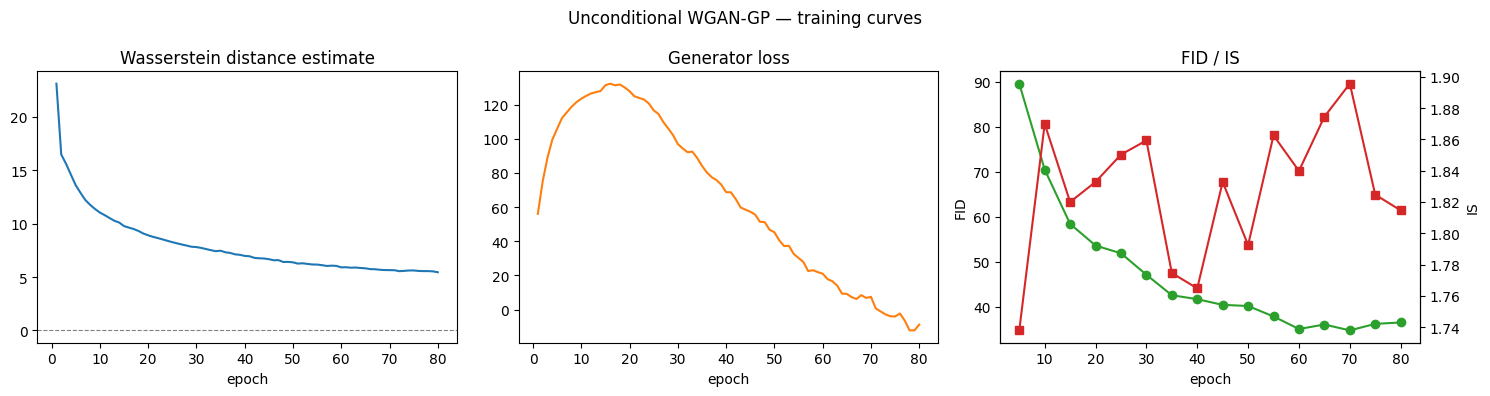

/tmp/ipykernel_359026/3657727668.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best = torch.load(LAB_DIR / "wgan_best.pth", map_location=device)
/home/greg/miniconda3/

Best unconditional model -> FID 34.99 | IS 1.85 ± 0.04


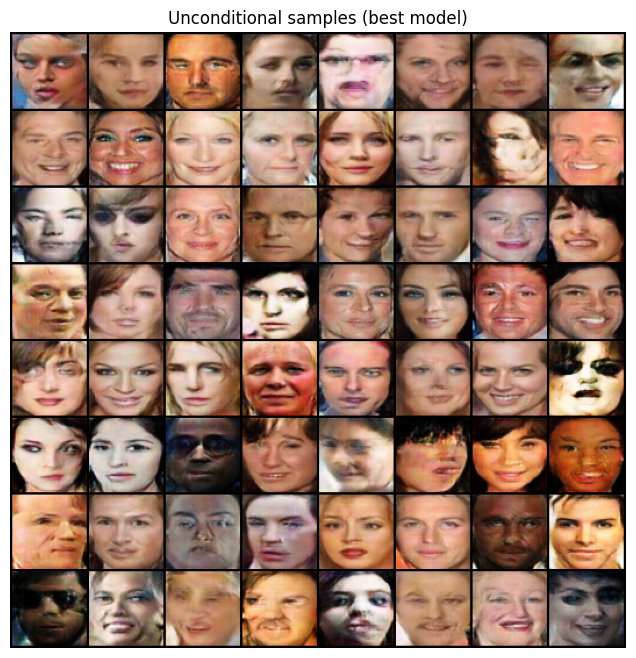

In [11]:
plot_curves(uncond_history, "Unconditional WGAN-GP — training curves")

best = torch.load(LAB_DIR / "wgan_best.pth", map_location=device)
gen.load_state_dict(best["gen"])
fid, is_mean, is_std = evaluate_fid_is(gen, crops_uint8, FID_N, Z_DIM, device)
print(f"Best unconditional model -> FID {fid:.2f} | IS {is_mean:.2f} ± {is_std:.2f}")

plt.figure(figsize=(8, 8))
plt.imshow(sample_grid(gen, uncond_fixed_z))
plt.axis("off"); plt.title("Unconditional samples (best model)"); plt.show()

## 10. Условная cWGAN-GP — модели


In [12]:
N_CLASSES = 2

class CondGenerator(nn.Module):
    def __init__(self, z_dim=Z_DIM, n_classes=N_CLASSES, embed_dim=EMBED_DIM, ngf=NGF):
        super().__init__()
        self.embed = nn.Embedding(n_classes, embed_dim)
        self.net = build_generator_net(z_dim + embed_dim, ngf)
    def forward(self, z, labels):
        e = self.embed(labels).unsqueeze(-1).unsqueeze(-1)
        return self.net(torch.cat([z, e], dim=1))

class CondCritic(nn.Module):
    def __init__(self, n_classes=N_CLASSES, img_size=IMG_SIZE, ndf=NDF):
        super().__init__()
        self.img_size = img_size
        self.embed = nn.Embedding(n_classes, img_size * img_size)
        self.net = build_critic_net(3 + 1, ndf)
    def forward(self, x, labels):
        e = self.embed(labels).view(-1, 1, self.img_size, self.img_size)
        return self.net(torch.cat([x, e], dim=1)).view(-1)

_g, _c = CondGenerator().to(device), CondCritic().to(device)
with torch.no_grad():
    _z = torch.randn(4, Z_DIM, 1, 1, device=device)
    _l = torch.randint(0, N_CLASSES, (4,), device=device)
    print("CondG out:", tuple(_g(_z, _l).shape), "| CondC out:", tuple(_c(_g(_z, _l), _l).shape))
del _g, _c

CondG out: (4, 3, 64, 64) | CondC out: (4,)


## 11. Обучение — условный cWGAN-GP

In [13]:
cgen = CondGenerator().to(device);  cgen.apply(weights_init)
ccritic = CondCritic().to(device);  ccritic.apply(weights_init)

cond_history, cond_fixed_z, cond_fixed_lbl = train_wgan_gp(
    cgen, ccritic, cond_loader, NUM_EPOCHS,
    ckpt_last=LAB_DIR / "cwgan_last.pth",
    ckpt_best=LAB_DIR / "cwgan_best.pth",
    samp_prefix=str(SAMP_DIR / "cond"),
    n_classes=N_CLASSES,
)

Resumed from checkpoint at epoch 80


/tmp/ipykernel_359026/797567245.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck = torch.load(path, map_location=device)


Epoch 1/1:   4%|▍         | 2/46 [00:01<00:18,  2.34it/s, g_loss=19.94, w_dist=25.39]

Epoch 1/1:   7%|▋         | 3/46 [00:01<00:14,  2.98it/s, g_loss=19.94, w_dist=25.39]

Epoch 1/1:   7%|▋         | 3/46 [00:01<00:14,  2.98it/s, g_loss=27.66, w_dist=35.63]

...

Epoch 1/1:  96%|█████████▌| 44/46 [00:10<00:00,  4.67it/s, g_loss=65.47, w_dist=46.77]

Epoch 1/1:  98%|█████████▊| 45/46 [00:10<00:00,  4.67it/s, g_loss=65.47, w_dist=46.77]

Epoch 1/1:  98%|█████████▊| 45/46 [00:10<00:00,  4.67it/s, g_loss=62.78, w_dist=44.55]

Epoch 1/1: 100%|██████████| 46/46 [00:10<00:00,  4.68it/s, g_loss=62.78, w_dist=44.55]

Epoch   1/1 | W-dist   59.11 | G-loss    56.43 | FID 271.8 | IS 1.56


## 12. Результаты условной модели — генерация с управлением по полу

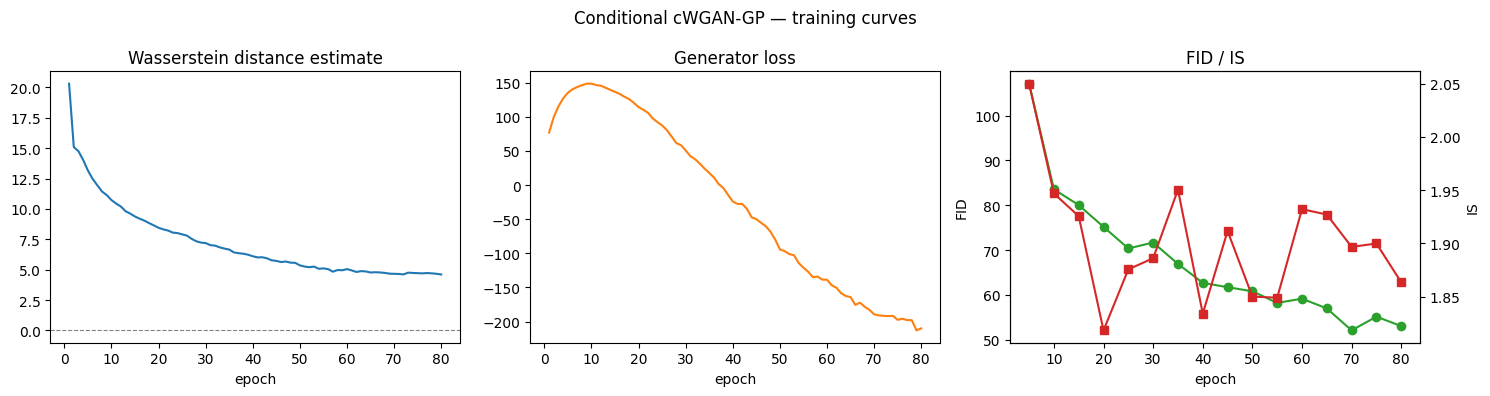

/tmp/ipykernel_359026/2774066417.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cbest = torch.load(LAB_DIR / "cwgan_best.pth", map_location=device)
/home/greg/miniconda

Best conditional model -> FID 53.17 | IS 1.90 ± 0.06


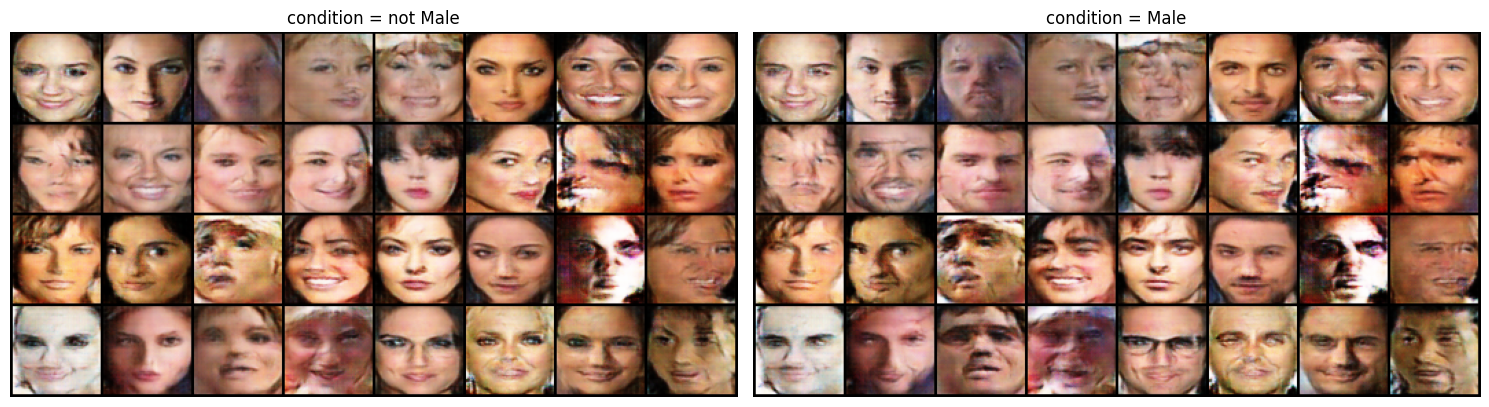

In [16]:
plot_curves(cond_history, "Conditional cWGAN-GP — training curves")

cbest = torch.load(LAB_DIR / "cwgan_best.pth", map_location=device)
cgen.load_state_dict(cbest["gen"])
cfid, cis_m, cis_s = evaluate_fid_is(cgen, crops_uint8, FID_N, Z_DIM, device, N_CLASSES)
print(f"Best conditional model -> FID {cfid:.2f} | IS {cis_m:.2f} ± {cis_s:.2f}")

z_shared = torch.randn(32, Z_DIM, 1, 1, device=device)
fig, axes = plt.subplots(1, 2, figsize=(15, 8))
for ax, cls, name in zip(axes, [0, 1], [f"not {ATTR}", ATTR]):
    lbl = torch.full((32,), cls, device=device, dtype=torch.long)
    ax.imshow(sample_grid(cgen, z_shared, lbl, nrow=8))
    ax.set_title(f"condition = {name}"); ax.axis("off")
plt.tight_layout(); plt.show()

## 13. Итоговая таблица метрик

In [15]:
summary = pd.DataFrame({
    "Model": ["Unconditional WGAN-GP", "Conditional cWGAN-GP (Male)"],
    "Best FID": [round(fid, 2), round(cfid, 2)],
    "IS": [f"{is_mean:.2f} ± {is_std:.2f}", f"{cis_m:.2f} ± {cis_s:.2f}"],
    "Epochs": [len(uncond_history["w_dist"]), len(cond_history["w_dist"])],
})
summary

,Model,Best FID,IS,Epochs
0,Unconditional WGAN-GP,34.99,1.85 ± 0.04,80
1,Conditional cWGAN-GP (Male),53.32,1.91 ± 0.04,80


## Заключение

### Использованные техники стабилизации обучения GAN

| Приём | Зачем |
|---|---|
| **Wasserstein-loss (WGAN)** | Earth-Mover distance даёт гладкие, не исчезающие градиенты даже когда распределения почти не пересекаются (главный failure mode ванильного GAN). |
| **Gradient penalty (WGAN-GP)** | Удерживает критика на 1-Lipschitz, штрафуя норму градиента к 1 — вместо weight clipping (которое теряет ёмкость и взрывает/занижает градиенты). |
| **`n_critic = 5`** | Держим критика близко к оптимуму — тогда оценка W-distance (и градиент для генератора) точная. |
| **Без BatchNorm в критике** | BN связывает сэмплы в батче, что несовместимо с per-sample gradient penalty; вместо BN — InstanceNorm. |
| **`Adam(β = (0.0, 0.9))`** | Низкий момент рекомендован для WGAN-GP; высокий β₁ дестабилизирует противоборство. |
| **DCGAN-архитектура** | `Strided (transpose-)conv + BatchNorm` в генераторе — проверенный устойчивый свёрточный backbone. |
| **Conditioning через конкатенацию** | Embedding метки идёт и в генератор (concat к `z` по каналу), и в критика (extra spatial channel) — минимальный, надёжный способ управлять генерацией. |
